In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt

In [2]:
os = xr.open_dataset('/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/test/ocean.stats.nc', decode_times=False)
os_short = xr.open_dataset('/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/test_short/ocean.stats.nc', decode_times=False)

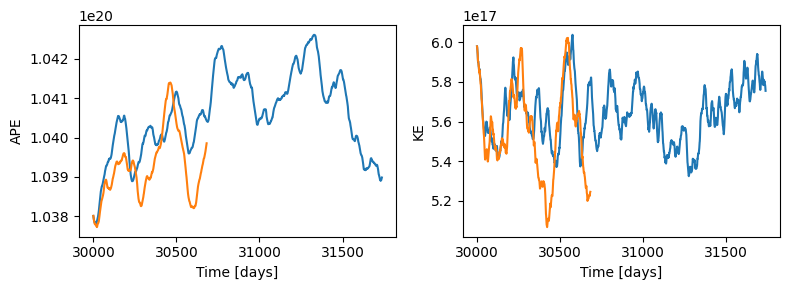

In [4]:
plt.figure(figsize=(8,3))

plt.subplot(1,2,1)
os.APE.sum('Interface').plot()
os_short.APE.sum('Interface').plot()

plt.subplot(1,2,2)
os.KE.sum('Layer').plot()
os_short.KE.sum('Layer').plot()

plt.tight_layout()

In [5]:
ds = xr.open_dataset('/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/test_short_more_diag/snapshots_00030210.nc',
                     decode_times=False)

## Check vhGM

In [2]:
path = '/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/test_20Dec_ANN/longmean_00036050.nc'
path = '/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/test/longmean_00036050.nc'
path  ='/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/R2-WENO/test_20Dec_ANN/longmean_00029050.nc'

ds_mean = xr.open_dataset(path, decode_times=False)

In [3]:
ds_mean

<xarray.Dataset> Size: 274MB
Dimensions:         (xq: 121, yh: 280, zl: 15, time: 10, nv: 2, xh: 120,
                     yq: 281, zi: 16)
Coordinates:
  * xq              (xq) float64 968B 0.0 0.5 1.0 1.5 ... 58.5 59.0 59.5 60.0
  * yh              (yh) float64 2kB -69.75 -69.25 -68.75 ... 68.75 69.25 69.75
  * zl              (zl) float64 120B 1.023e+03 1.023e+03 ... 1.028e+03
  * time            (time) float64 80B 2.905e+04 2.915e+04 ... 2.995e+04
  * nv              (nv) float64 16B 1.0 2.0
  * xh              (xh) float64 960B 0.25 0.75 1.25 1.75 ... 58.75 59.25 59.75
  * yq              (yq) float64 2kB -70.0 -69.5 -69.0 -68.5 ... 69.0 69.5 70.0
  * zi              (zi) float64 128B 1.022e+03 1.023e+03 ... 1.028e+03
Data variables: (12/20)
    u               (time, zl, yh, xq) float32 20MB ...
    v               (time, zl, yq, xh) float32 20MB ...
    h               (time, zl, yh, xh) float32 20MB ...
    e               (time, zi, yh, xh) float32 22MB ...
    uh              (time, zl, yh, xq) float32 20MB ...
    vh              (time, zl, yq, xh) float32 20MB ...
    ...              ...
    GM_sfn_x        (time, zi, yh, xq) float32 22MB ...
    GM_sfn_y        (time, zi, yq, xh) float32 22MB ...
    average_T1      (time) float64 80B ...
    average_T2      (time) float64 80B ...
    average_DT      (time) float64 80B ...
    time_bnds       (time, nv) float64 160B ...
Attributes:
    filename:          longmean_00029050.nc
    title:             NeverWorld2
    associated_files:  area_t: static.nc
    grid_type:         regular
    grid_tile:         N/A

In [4]:
import xgcm

# Create the grid object (adjust axis definitions to match your dataset)
grid = xgcm.Grid(ds_mean, coords={
    'X': {'center': 'xh', 'outer': 'xq'},
    'Y': {'center': 'yh', 'outer': 'yq'},
    'Z': {'center': 'zl', 'outer': 'zi'}
}, periodic=['X'])

# Interpolate e from yh to yq
e_on_yq = grid.interp(ds_mean.e, 'Y', boundary='extend')

# Average over x and time
vhGM_mean = ds_mean.vhGM.mean(['xh', 'time'])
e_mean = e_on_yq.mean(['xh', 'time'])

/ext3/miniconda3/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


Text(0, 0.5, 'Depth [m]')

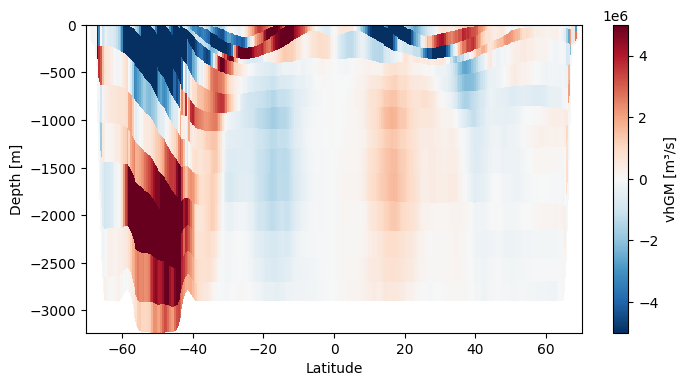

In [6]:
# Create y-edges for v-point cells: 562 edges for 561 cell centers
yq = vhGM_mean.yq.values
dy = np.diff(yq)
yq_edges = np.concatenate([[yq[0] - dy[0]/2], 
                           0.5 * (yq[:-1] + yq[1:]), 
                           [yq[-1] + dy[-1]/2]])  # (562,)

# Extend e to y-edges: (16, 562)
e_filled = np.where(np.isfinite(e_mean.values), e_mean.values, 0)
e_edges = np.column_stack([e_filled[:, 0],
                           0.5 * (e_filled[:, :-1] + e_filled[:, 1:]),
                           e_filled[:, -1]])  # (16, 562)

fig, ax = plt.subplots(figsize=(8, 4))
pcm = ax.pcolormesh(yq_edges, e_edges, vhGM_mean.values, 
                    shading='flat', cmap='RdBu_r', vmin=-5e6, vmax=5e6)
plt.colorbar(pcm, label='vhGM [m³/s]')
ax.set_xlabel('Latitude')
ax.set_ylabel('Depth [m]')

Text(0, 0.5, 'Depth [m]')

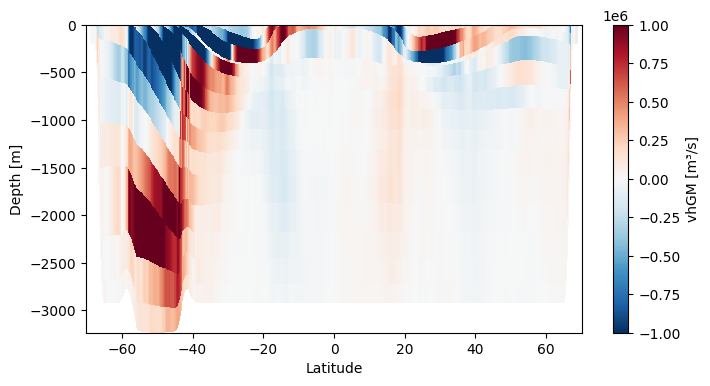

In [6]:
# Create y-edges for v-point cells: 562 edges for 561 cell centers
yq = vhGM_mean.yq.values
dy = np.diff(yq)
yq_edges = np.concatenate([[yq[0] - dy[0]/2], 
                           0.5 * (yq[:-1] + yq[1:]), 
                           [yq[-1] + dy[-1]/2]])  # (562,)

# Extend e to y-edges: (16, 562)
e_filled = np.where(np.isfinite(e_mean.values), e_mean.values, 0)
e_edges = np.column_stack([e_filled[:, 0],
                           0.5 * (e_filled[:, :-1] + e_filled[:, 1:]),
                           e_filled[:, -1]])  # (16, 562)

fig, ax = plt.subplots(figsize=(8, 4))
pcm = ax.pcolormesh(yq_edges, e_edges, vhGM_mean.values, 
                    shading='flat', cmap='RdBu_r', vmin=-1e6, vmax=1e6)
plt.colorbar(pcm, label='vhGM [m³/s]')
ax.set_xlabel('Latitude')
ax.set_ylabel('Depth [m]')

Text(0, 0.5, 'Depth [m]')

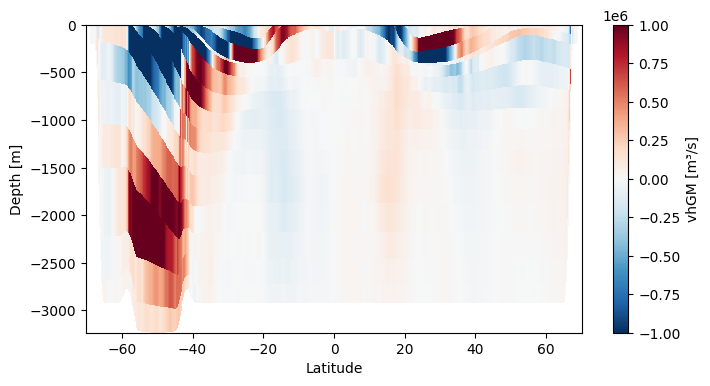

In [10]:
# Create y-edges for v-point cells: 562 edges for 561 cell centers
yq = vhGM_mean.yq.values
dy = np.diff(yq)
yq_edges = np.concatenate([[yq[0] - dy[0]/2], 
                           0.5 * (yq[:-1] + yq[1:]), 
                           [yq[-1] + dy[-1]/2]])  # (562,)

# Extend e to y-edges: (16, 562)
e_filled = np.where(np.isfinite(e_mean.values), e_mean.values, 0)
e_edges = np.column_stack([e_filled[:, 0],
                           0.5 * (e_filled[:, :-1] + e_filled[:, 1:]),
                           e_filled[:, -1]])  # (16, 562)

fig, ax = plt.subplots(figsize=(8, 4))
pcm = ax.pcolormesh(yq_edges, e_edges, vhGM_mean.values, 
                    shading='flat', cmap='RdBu_r', vmin=-1e6, vmax=1e6)
plt.colorbar(pcm, label='vhGM [m³/s]')
ax.set_xlabel('Latitude')
ax.set_ylabel('Depth [m]')

In [6]:
ds_mean = xr.open_dataset('

<xarray.Dataset> Size: 2GB
Dimensions:          (xq: 241, yh: 560, zl: 15, time: 10, xh: 240, yq: 561,
                      zi: 16)
Coordinates:
  * xq               (xq) float64 2kB 0.0 0.25 0.5 0.75 ... 59.5 59.75 60.0
  * yh               (yh) float64 4kB -69.88 -69.62 -69.38 ... 69.38 69.62 69.88
  * zl               (zl) float64 120B 1.023e+03 1.023e+03 ... 1.028e+03
  * time             (time) float64 80B 3.021e+04 3.022e+04 ... 3.03e+04
  * xh               (xh) float64 2kB 0.125 0.375 0.625 ... 59.38 59.62 59.88
  * yq               (yq) float64 4kB -70.0 -69.75 -69.5 ... 69.5 69.75 70.0
  * zi               (zi) float64 128B 1.022e+03 1.023e+03 ... 1.028e+03
Data variables: (12/17)
    u                (time, zl, yh, xq) float32 81MB ...
    v                (time, zl, yq, xh) float32 81MB ...
    h                (time, zl, yh, xh) float32 81MB ...
    e                (time, zi, yh, xh) float64 172MB ...
    RV               (time, zl, yq, xq) float32 81MB ...
    uh               (time, zl, yh, xq) float32 81MB ...
    ...               ...
    GM_sfn_x         (time, zi, yh, xq) float32 86MB ...
    GM_sfn_y         (time, zi, yq, xh) float32 86MB ...
    meso_sfn_drdx_u  (time, zi, yh, xq) float32 86MB ...
    meso_sfn_drdy_v  (time, zi, yq, xh) float32 86MB ...
    meso_sfn_drdz_u  (time, zi, yh, xq) float32 86MB ...
    meso_sfn_drdz_v  (time, zi, yq, xh) float32 86MB ...
Attributes:
    filename:          snapshots_00030210.nc
    title:             NeverWorld2
    associated_files:  area_t: static.nc
    grid_type:         regular
    grid_tile:         N/A

In [10]:
ds = xr.open_dataset('/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/test/output/debugs_00030000.nc', decode_times=False)

In [7]:
ds2 = xr.open_dataset('/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/test/debugs_00030004.nc', decode_times=False)

In [ ]:
#ds = xr.open_mfdataset('/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/test/output/debugs_000300*.nc', decode_times=False)

In [3]:
os = xr.open_dataset('/home/db194/scratch_db194/mom6/dec2025/NeverWorld2/test/output/ocean.stats.nc', decode_times=False)

In [5]:
ds

<xarray.Dataset> Size: 13kB
Dimensions:          (xq: 241, yh: 560, zl: 15, time: 0, xh: 240, yq: 561,
                      zi: 16)
Coordinates:
  * xq               (xq) float64 2kB 0.0 0.25 0.5 0.75 ... 59.5 59.75 60.0
  * yh               (yh) float64 4kB -69.88 -69.62 -69.38 ... 69.38 69.62 69.88
  * zl               (zl) float64 120B 1.023e+03 1.023e+03 ... 1.028e+03
  * time             (time) float64 0B 
  * xh               (xh) float64 2kB 0.125 0.375 0.625 ... 59.38 59.62 59.88
  * yq               (yq) float64 4kB -70.0 -69.75 -69.5 ... 69.5 69.75 70.0
  * zi               (zi) float64 128B 1.022e+03 1.023e+03 ... 1.028e+03
Data variables: (12/17)
    u                (time, zl, yh, xq) float32 0B ...
    v                (time, zl, yq, xh) float32 0B ...
    h                (time, zl, yh, xh) float32 0B ...
    e                (time, zi, yh, xh) float64 0B ...
    RV               (time, zl, yq, xq) float32 0B ...
    uh               (time, zl, yh, xq) float32 0B ...
    ...               ...
    GM_sfn_x         (time, zi, yh, xq) float32 0B ...
    GM_sfn_y         (time, zi, yq, xh) float32 0B ...
    meso_sfn_drdx_u  (time, zi, yh, xq) float32 0B ...
    meso_sfn_drdy_v  (time, zi, yq, xh) float32 0B ...
    meso_sfn_drdz_u  (time, zi, yh, xq) float32 0B ...
    meso_sfn_drdz_v  (time, zi, yq, xh) float32 0B ...
Attributes:
    filename:          debugs_00030001.nc
    title:             NeverWorld2
    associated_files:  area_t: static.nc
    grid_type:         regular
    grid_tile:         N/A

In [5]:
os.Ntrunc.values

array([     0.,  12917., 229305.])

In [6]:
os.max_CFL_trans.values

array([0.08108061, 0.49993306, 0.49996277])

In [11]:
ds

<xarray.Dataset> Size: 453MB
Dimensions:          (xq: 241, yh: 560, zl: 15, time: 3, xh: 240, yq: 561,
                      zi: 16)
Coordinates:
  * xq               (xq) float64 2kB 0.0 0.25 0.5 0.75 ... 59.5 59.75 60.0
  * yh               (yh) float64 4kB -69.88 -69.62 -69.38 ... 69.38 69.62 69.88
  * zl               (zl) float64 120B 1.023e+03 1.023e+03 ... 1.028e+03
  * time             (time) float64 24B 3e+04 3e+04 3e+04
  * xh               (xh) float64 2kB 0.125 0.375 0.625 ... 59.38 59.62 59.88
  * yq               (yq) float64 4kB -70.0 -69.75 -69.5 ... 69.5 69.75 70.0
  * zi               (zi) float64 128B 1.022e+03 1.023e+03 ... 1.028e+03
Data variables: (12/17)
    u                (time, zl, yh, xq) float32 24MB ...
    v                (time, zl, yq, xh) float32 24MB ...
    h                (time, zl, yh, xh) float32 24MB ...
    e                (time, zi, yh, xh) float64 52MB ...
    RV               (time, zl, yq, xq) float32 24MB ...
    uh               (time, zl, yh, xq) float32 24MB ...
    ...               ...
    GM_sfn_x         (time, zi, yh, xq) float32 26MB ...
    GM_sfn_y         (time, zi, yq, xh) float32 26MB ...
    meso_sfn_drdx_u  (time, zi, yh, xq) float32 26MB ...
    meso_sfn_drdy_v  (time, zi, yq, xh) float32 26MB ...
    meso_sfn_drdz_u  (time, zi, yh, xq) float32 26MB ...
    meso_sfn_drdz_v  (time, zi, yq, xh) float32 26MB ...
Attributes:
    filename:          debugs_00030000.nc
    title:             NeverWorld2
    associated_files:  area_t: static.nc
    grid_type:         regular
    grid_tile:         N/A

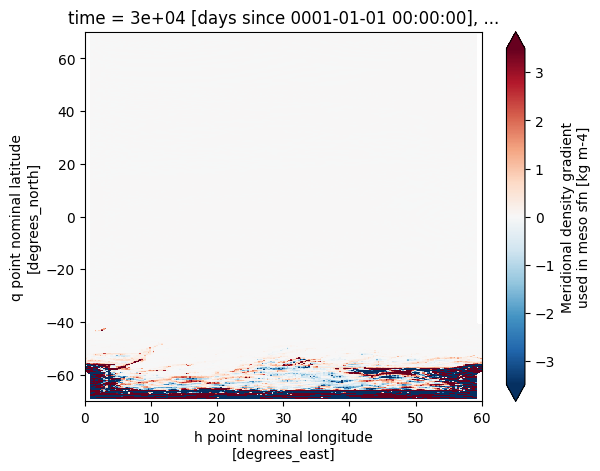

In [12]:
ds.meso_sfn_drdy_v.isel(time=0, zi=2).plot(robust=True)

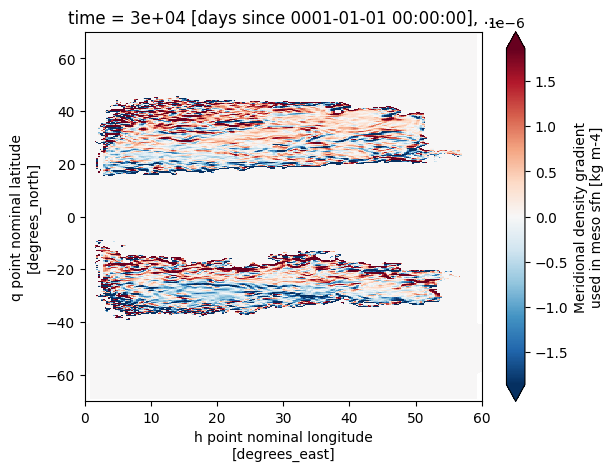

In [13]:
ds2.meso_sfn_drdy_v.isel(time=0, zi=2).plot(robust=True)

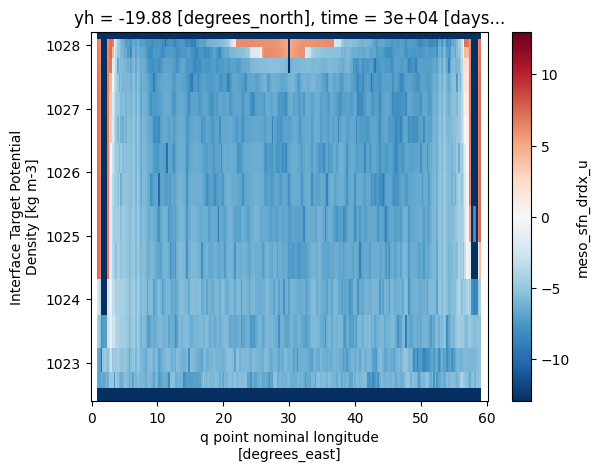

In [14]:
np.log10(np.abs(ds.meso_sfn_drdx_u)+1e-13).isel(time=-1).sel(yh=-20,method='nearest').plot(robust=True)

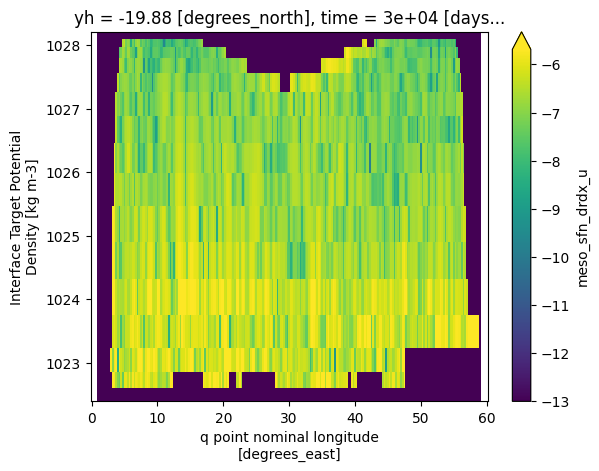

In [15]:
np.log10(np.abs(ds2.meso_sfn_drdx_u)+1e-13).isel(time=-1).sel(yh=-20,method='nearest').plot(robust=True)

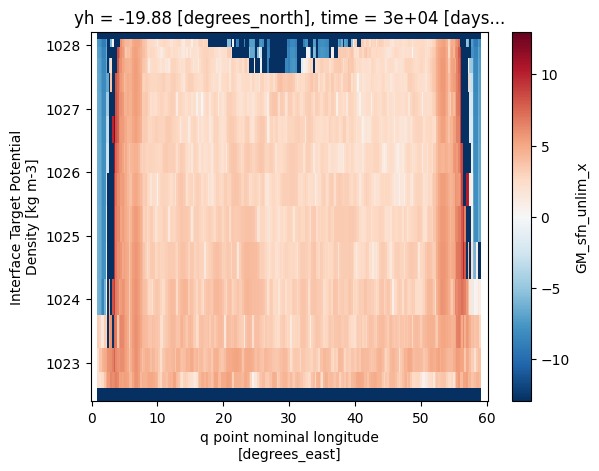

In [16]:
np.log10(np.abs(ds.GM_sfn_unlim_x)+1e-13).isel(time=-1).sel(yh=-20,method='nearest').plot(robust=True)

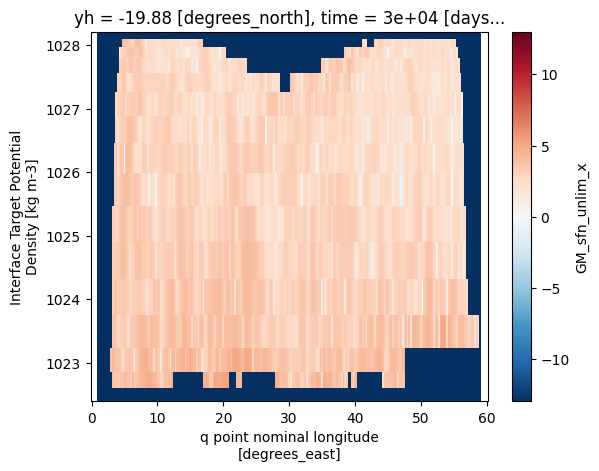

In [17]:
np.log10(np.abs(ds2.GM_sfn_unlim_x)+1e-13).isel(time=-1).sel(yh=-20,method='nearest').plot(robust=True)

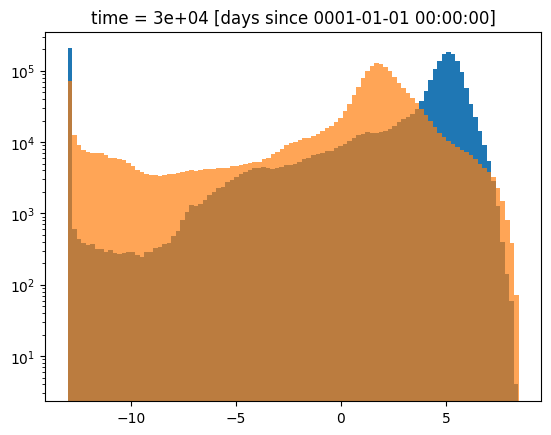

In [18]:
np.log10(np.abs(ds.vh)+1e-13).isel(time=0).plot.hist(bins=100);
np.log10(np.abs(ds.vhGM/ds.zl)+1e-13).isel(time=0).plot.hist(bins=100, alpha=0.7);
plt.yscale('log')

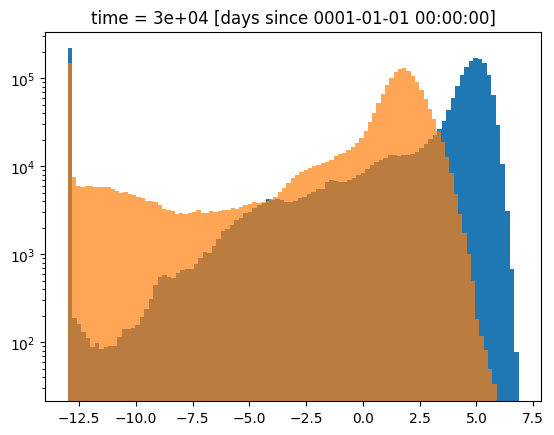

In [19]:
np.log10(np.abs(ds2.vh)+1e-13).isel(time=0).plot.hist(bins=100);
np.log10(np.abs(ds2.vhGM/ds2.zl)+1e-13).isel(time=0).plot.hist(bins=100, alpha=0.7);
plt.yscale('log')

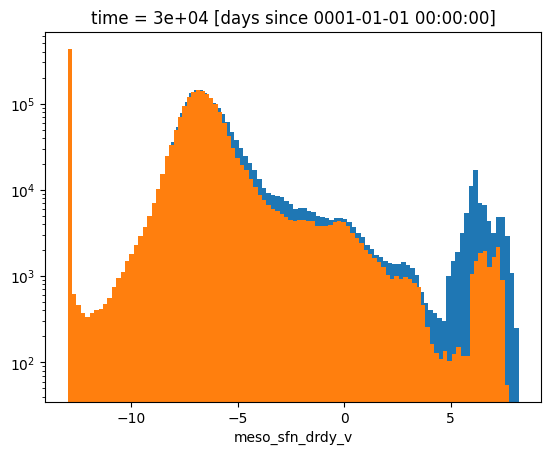

In [20]:
np.log10(np.abs(ds.meso_sfn_drdx_u)+1e-13).isel(time=0).plot.hist(bins=100);
np.log10(np.abs(ds.meso_sfn_drdy_v)+1e-13).isel(time=0).plot.hist(bins=100);
plt.yscale('log')

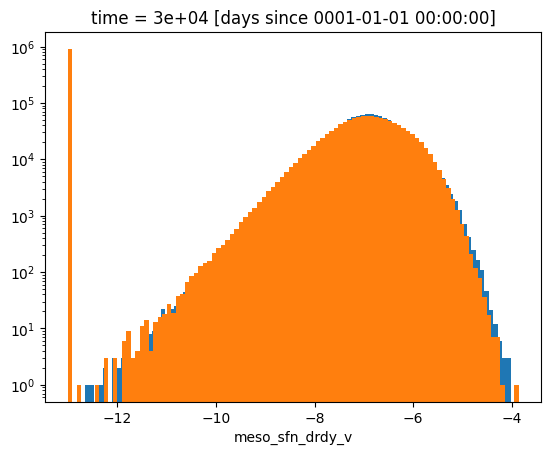

In [21]:
np.log10(np.abs(ds2.meso_sfn_drdx_u)+1e-13).isel(time=0).plot.hist(bins=100);
np.log10(np.abs(ds2.meso_sfn_drdy_v)+1e-13).isel(time=0).plot.hist(bins=100);
plt.yscale('log')

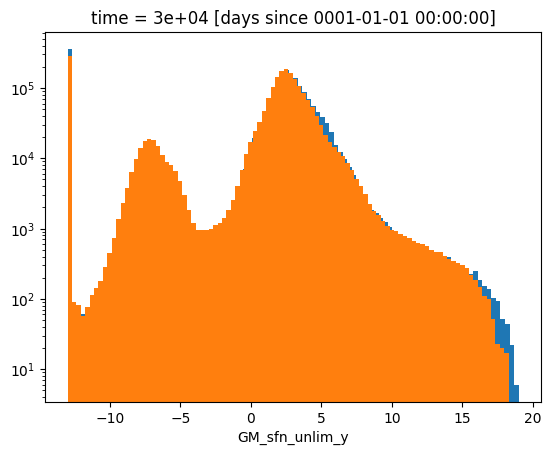

In [22]:
np.log10(np.abs(ds.GM_sfn_unlim_x)+1e-13).isel(time=0).plot.hist(bins=100);
np.log10(np.abs(ds.GM_sfn_unlim_y)+1e-13).isel(time=0).plot.hist(bins=100);
plt.yscale('log')

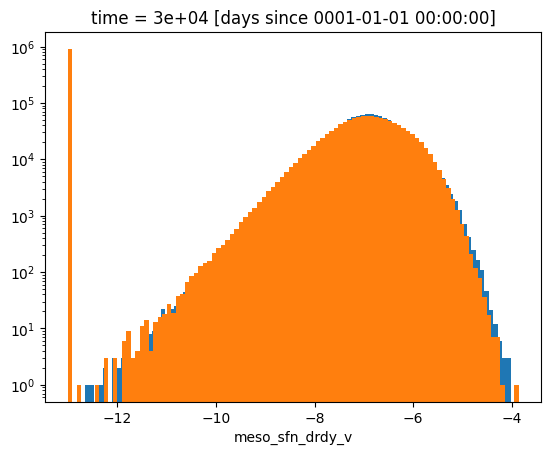

In [23]:
np.log10(np.abs(ds2.meso_sfn_drdx_u)+1e-13).isel(time=0).plot.hist(bins=100);
np.log10(np.abs(ds2.meso_sfn_drdy_v)+1e-13).isel(time=0).plot.hist(bins=100);
plt.yscale('log')

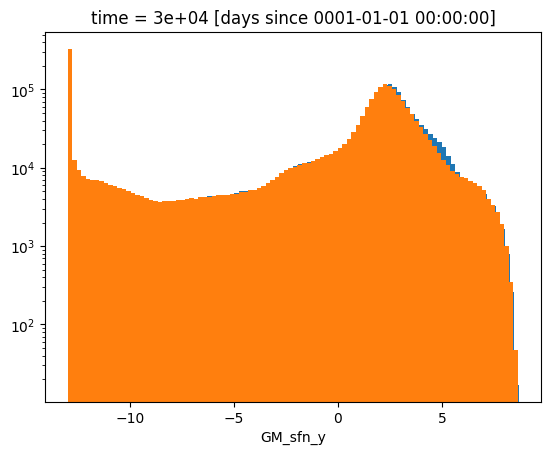

In [24]:
np.log10(np.abs(ds.GM_sfn_x)+1e-13).isel(time=0).plot.hist(bins=100);
np.log10(np.abs(ds.GM_sfn_y)+1e-13).isel(time=0).plot.hist(bins=100);
plt.yscale('log')

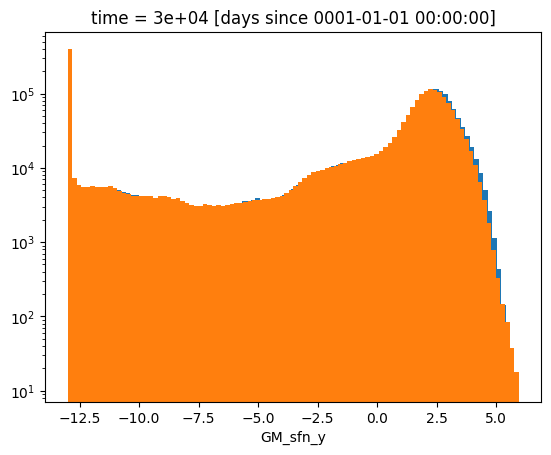

In [25]:
np.log10(np.abs(ds2.GM_sfn_x)+1e-13).isel(time=0).plot.hist(bins=100);
np.log10(np.abs(ds2.GM_sfn_y)+1e-13).isel(time=0).plot.hist(bins=100);
plt.yscale('log')

In [16]:
ds.zl.diff('zl')/1e3

<xarray.DataArray 'zl' (zl: 14)> Size: 112B
array([0.00021, 0.00039, 0.00054, 0.00058, 0.00058, 0.00057, 0.00053,
       0.00048, 0.00042, 0.00037, 0.00031, 0.00024, 0.00017, 0.00011])
Coordinates:
  * zl       (zl) float64 112B 1.023e+03 1.023e+03 ... 1.028e+03 1.028e+03

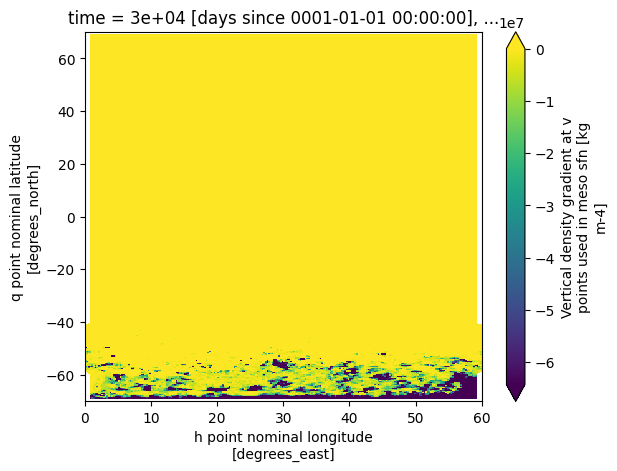

In [14]:
ds.meso_sfn_drdz_v.isel(time=0, zi=2).plot(robust=True)

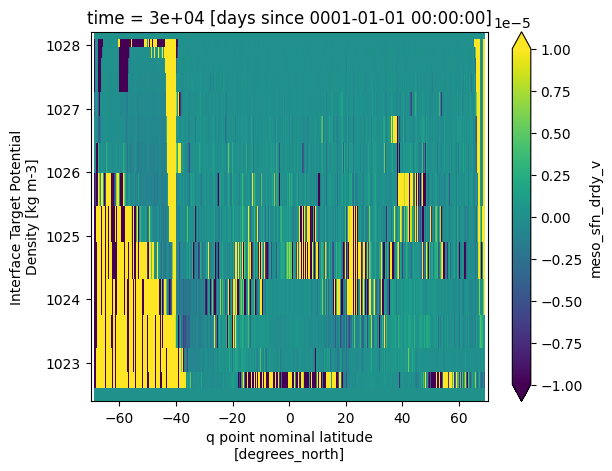

In [31]:
ds.meso_sfn_drdy_v.isel(time=-1).mean('xh').plot(vmin=-1e-5, vmax=1e-5)

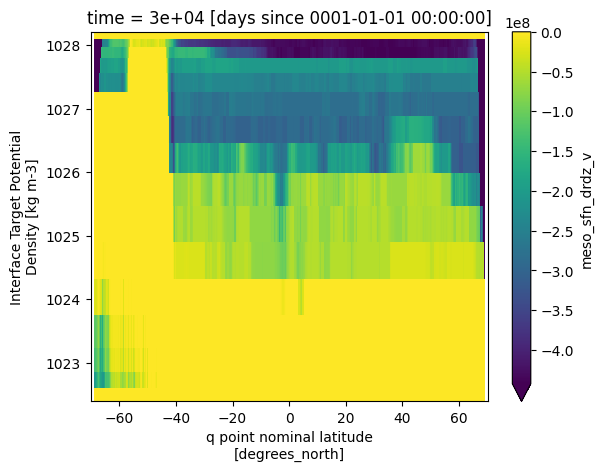

In [28]:
ds.meso_sfn_drdz_v.isel(time=-1).mean('xh').plot(robust=True)

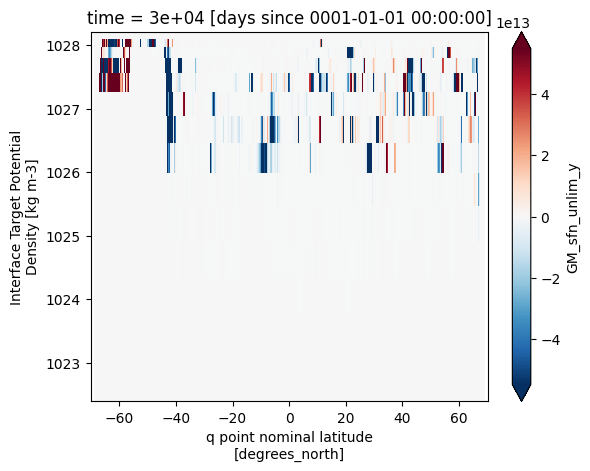

In [27]:
ds.GM_sfn_unlim_y.isel(time=-1).mean('xh').plot(robust=True)

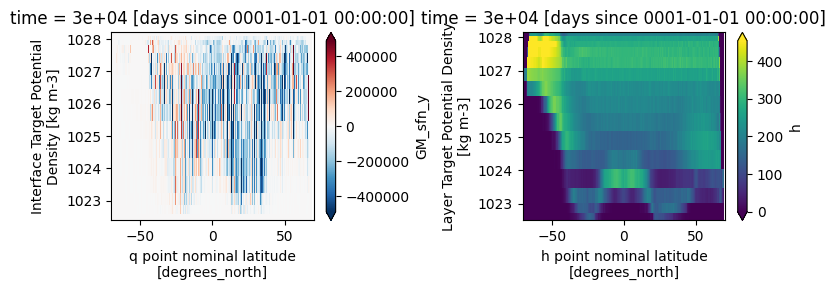

In [32]:
plt.figure(figsize=(8, 3))

plt.subplot(121)
ds.GM_sfn_y.isel(time=-1).mean('xh').plot(robust=True)

plt.subplot(122)
ds.h.isel(time=-1).mean('xh').plot(robust=True)

plt.tight_layout()

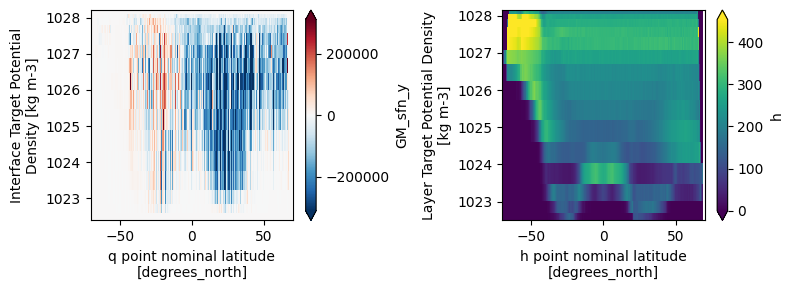

In [33]:
plt.figure(figsize=(8, 3))

plt.subplot(121)
ds.GM_sfn_y.mean(['xh','time']).plot(robust=True)

plt.subplot(122)
ds.h.mean(['xh','time']).plot(robust=True)

plt.tight_layout()

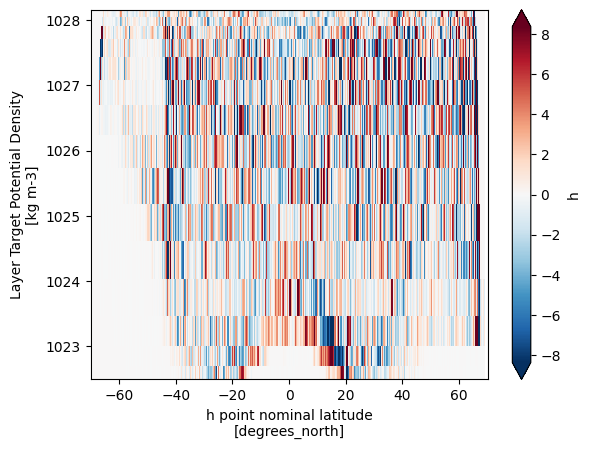

In [34]:
(ds.h.mean(['xh']).isel(time=-1) - ds.h.mean(['xh']).isel(time=0)).plot(robust=True)